<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº 2 - MODELIZANDO UN ADC
#### HOFFENREICH JULIETA


# Introducción

En este trabajo se simuló el proceso de digitalización de una señal analógica mediante un convertidor analógico-digital (ADC). Para ello se consideró una señal senoidal ideal $s$, a la cual se le agregó una secuencia de ruido analógico $n$, obteniéndose la señal de entrada al ADC: $s_R=s+n$. Luego del proceso de cuantización se obtiene la señal $s_Q$, correspondiente a la salida del ADC.

La señal senoidal se generó con una frecuencia de muestreo $f_s=1000\ \text{Hz}$ y una cantidad de muestras $N=1000$. Por lo tanto, la resolución frecuencial resulta $\Delta f=f_s/N=1\ \text{Hz}$. Se eligió además una frecuencia $f_0=\Delta f=1\ \text{Hz}$, de manera que la senoidal coincidiera exactamente con uno de los bins de la DFT.

La señal se definió con media nula y potencia unitaria. Para una senoidal de amplitud $A$, la potencia está dada por $P_s=A^2/2$. Por lo tanto, imponiendo $P_s=1$, se obtiene $A=\sqrt{2}$.

El ADC se caracterizó mediante una cantidad de bits $B$ y un rango analógico de entrada de $\pm V_F$. La cantidad de niveles disponibles es $2^B$ y el paso de cuantización, es decir, la separación entre niveles consecutivos, resulta:

$$q=\frac{2V_F}{2^B}$$

El proceso de cuantización consiste en aproximar cada muestra de la señal de entrada al nivel permitido más cercano. En la simulación se implementó como:

$$s_Q=q\cdot \operatorname{round}\left(\frac{s_R}{q}\right)$$

A partir de esto se definió el error o ruido de cuantización como $n_q=s_Q-s_R$. Para un cuantizador ideal por redondeo, este error queda limitado aproximadamente al intervalo $[-q/2,\ q/2]$, y su potencia teórica está dada por:

$$P_q=\frac{q^2}{12}$$

Dicho error, bajo el modelo ideal de cuantización, se considera aproximadamente uniforme, de media nula e incorrelado entre muestras. En estas condiciones puede modelarse como un ruido aproximadamente blanco, cuya autocorrelación presenta un máximo en retardo nulo y valores cercanos a cero para los demás retardos.

Además, se incorporó un ruido analógico $n$ de distribución gaussiana y media nula. Su potencia se definió como:
$$P_n=k_nP_q$$

donde $k_n$ permite controlar la relación entre la potencia del ruido analógico y la potencia del ruido de cuantización. Para generar dicho ruido se utilizó un desvío estándar $\sigma_n=\sqrt{P_n}$, de manera que su varianza resultara aproximadamente igual a $P_n$.

A partir de estas señales se estudió el comportamiento del sistema tanto en el dominio temporal como en el dominio de la frecuencia. Se analizaron la entrada y salida del ADC, las características estadísticas del error de cuantización, su autocorrelación y su distribución espectral. Finalmente, se estudió el efecto de modificar $k_n$ y la cantidad de bits $B$ sobre el comportamiento del convertidor y sobre la relación señal-ruido obtenida.


# Análisis y Resultados
### a) Caso $B=4$ y $k_n=1$

Para comenzar, se trabajó con un ADC de $B=4$ bits y $k_n=1$. En estas condiciones, el paso de cuantización resulta $q=0.25$ V y la potencia del ruido analógico se iguala a la potencia teórica del ruido de cuantización, ya que $P_n=1 P_q=P_q$.

A partir de los parámetros definidos previamente se generaron la señal senoidal ideal $s$, el ruido analógico $n$, la señal de entrada al ADC $s_R=s+n$, la señal cuantizada $s_Q$ y el error de cuantización $n_q=s_Q-s_R$.

En primer lugar, se analizaron las señales en el *dominio temporal*.

Potencia de s = 1.0000000000000002
Potencia medida de n = 0.005451887544725336
Potencia teorica de n = 0.005208333333333333


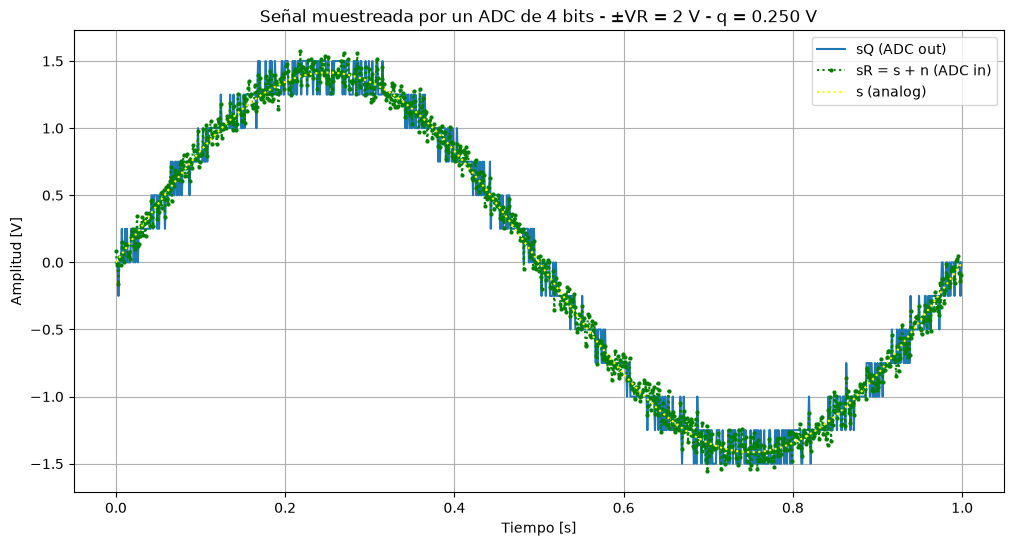

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

#%% DEFINO PARAMETROS

fs = 1000
N = 1000
B = 4
vfs = 2
kn = 1

delta_f = fs/N
f0 = delta_f#sera la frecuencia de mi senoidal

#%% FUNCIONES
def mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=N, fs=fs):

    tt = np.arange(0, nn/fs, 1/fs)

    xx = dc + vmax * np.sin(2*np.pi*ff*tt + ph)

    return tt, xx

#%% SENAL SENOIDAL
vmax = np.sqrt(2)#para que tenga potencia unitaria
tt, s = mi_funcion_sen(vmax=vmax,dc=0,ff=f0,ph=0,nn=N,fs=fs)
Ps = np.var(s)
print("Potencia de s =", Ps)

#%% ADC

q = (2*vfs)/(2**B)
Pq = q**2 / 12 #potencia del ruido cuantizado
Pn = kn * Pq # potencia del ruido analogico

sigma_n = np.sqrt(Pn)#desvio estandar, para generar el ruido analogico

n = np.random.normal(0,sigma_n,N)#generamos el ruido analg, con distrib gaussiana, de media 0 y varianza=

print("Potencia medida de n =", np.var(n))
print("Potencia teorica de n =", Pn)

sR = s + n #senal de entrada al ADC, senoidal + ruido analog
sQ = np.round(sR/q) * q #salida del ADC, cuantizacion
nq = sQ - sR #ruido cuantizacion

#%% ej a) 
#GRAFICO TEMPORAL
plt.figure(figsize=(12,6))
plt.plot(tt, sQ,label='sQ (ADC out)')
plt.plot(tt, sR,linestyle=':',marker='o',markersize=2,color='green',label='sR = s + n (ADC in)')
plt.plot(tt, s,linestyle=':',label='s (analog)', color='yellow')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.title( f'Señal muestreada por un ADC de {B} bits - '
    f'±VR = {vfs} V - q = {q:.3f} V')
plt.grid()
plt.legend()
plt.show()

Antes de analizar las señales, se verificó numéricamente que la potencia de la senoidal fuera aproximadamente unitaria y que la potencia medida del ruido analógico coincidiera con el valor teórico definido a partir de $P_n=k_nP_q$. Los resultados obtenidos fueron los esperados.

En la *representación temporal* se observa que la señal ideal presenta un período de aproximadamente $1$ s, consistente con la frecuencia elegida de $f_0=1$ Hz, y una amplitud máxima cercana a $\sqrt{2}$ V como se esperaba.

La señal $s_R$ aparece dispersa alrededor de la senoidal ideal debido al ruido gaussiano agregado antes del ADC. Por su parte, la salida $s_Q$ sigue la evolución de la señal de entrada, pero únicamente puede tomar valores pertenecientes a los niveles de cuantización disponibles.

Como para este caso $q=0.25$ V, estos niveles se encuentran separados entre sí por $0.25$ V, lo que da lugar a los escalones observados en la señal de salida.

Luego se analizó el error de cuantización $n_q$, con el objetivo de verificar si su comportamiento coincidía con el modelo teórico esperado para un cuantizador ideal.

En primer lugar, se representó $n_q$ en función del tiempo. Como $q=0.25$ V V, se espera que el error permanezca limitado al intervalo $[-q/2,\ q/2]$, es decir, entre -0.125 V y 0.125 V.


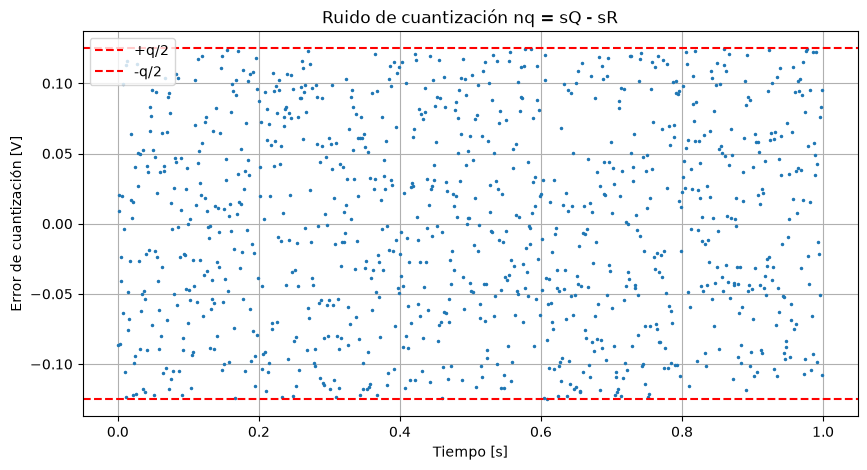

In [11]:
#RUIDO DE CUANTIZACION EN EL TIEMPO - esto no va en el tp

plt.figure(figsize=(10,5))
plt.plot(tt, nq,linestyle='None',marker='.',markersize=3)
plt.axhline(q/2, color='red', linestyle='--', label='+q/2')
plt.axhline(-q/2, color='red', linestyle='--', label='-q/2')
plt.xlabel('Tiempo [s]')
plt.ylabel('Error de cuantización [V]')
plt.title('Ruido de cuantización nq = sQ - sR')
plt.grid()
plt.legend()
plt.show()

Como se observa en el gráfico, los valores del error permanecen dentro de los límites teóricos, lo que coincide con el comportamiento esperado para un cuantizador por redondeo.

Para estudiar cómo se distribuyen los valores del error de cuantización se realizó un *histograma*. El modelo teórico considera que $n_q$ puede aproximarse mediante una distribución uniforme dentro del intervalo $[-q/2,\ q/2]$.

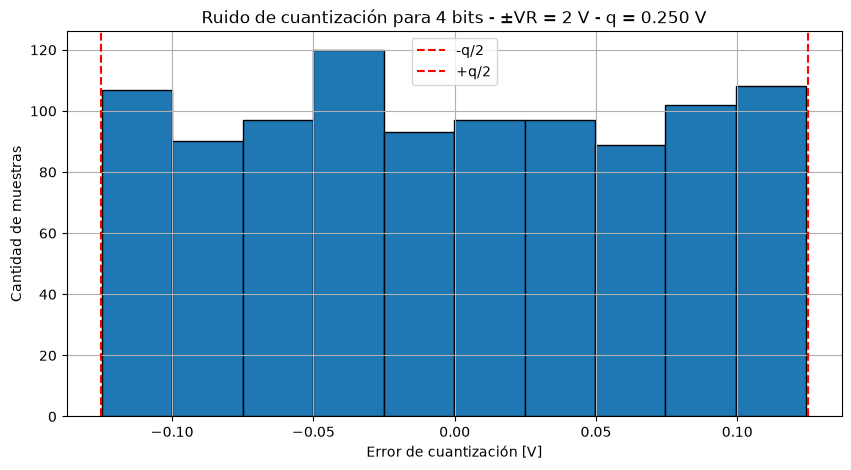

In [12]:
#%% HISTOGRAMA DEL RUIDO DE CUANTIZACION

plt.figure(figsize=(10,5))
plt.hist(nq,bins=10,edgecolor='black')
plt.axvline(-q/2,color='red',linestyle='--',label='-q/2')
plt.axvline(q/2,color='red',linestyle='--',label='+q/2')
plt.xlabel('Error de cuantización [V]')
plt.ylabel('Cantidad de muestras')
plt.title(f'Ruido de cuantización para {B} bits - '
    f'±VR = {vfs} V - q = {q:.3f} V')
plt.grid()
plt.legend()
plt.show()

El histograma presenta una forma aproximadamente uniforme dentro del intervalo esperado. Sin embargo, esta observación visual no alcanza para afirmar que el error de cuantización sigue una distribución uniforme. Por este motivo, se complementó el análisis calculando la media y la varianza y, finalmente, aplicando el test de $Kolmogorov-Smirnov$.


In [6]:
#%% MEDIA Y VARIANZA DEL RUIDO DE CUANTIZACION
#condiciones necesarias pero no suficientes para que sea uniforme
media_nq = np.mean(nq)
var_nq = np.var(nq)

var_teorica = q**2 / 12

print("Media nq =", media_nq)
print("Varianza medida nq =", var_nq)
print("Varianza teórica q^2/12 =", var_teorica)

# Kolmogorov-Smirnov test

# límites teóricos de la distribución uniforme
a = -q/2
b = q/2

resultado = stats.kstest(nq,'uniform',args=(a, b-a))

alpha = 0.05

print("p-value =", resultado.pvalue)

if resultado.pvalue > alpha:
    print("La señal es compatible con una distribución uniforme.")
else:
    print("La señal NO es compatible con una distribución uniforme.")

Media nq = -0.0016756135867022346
Varianza medida nq = 0.005209572837043794
Varianza teórica q^2/12 = 0.005208333333333333
p-value = 0.8196492041345727
La señal es compatible con una distribución uniforme.


Observamos que la media obtenida resultó cercana a cero y la varianza medida fue próxima al valor teórico $q^2/12$, por lo que ambos resultados son consistentes con el modelo esperado del error de cuantización.
En cuanto al test de Kolmogorov-Smirnov, se utilizó un nivel de significancia $\alpha=0.05$ y se obtuvo un valor $p=0.217$. Como $p>\alpha$, no se rechaza la hipótesis de compatibilidad con una distribución uniforme.

Por lo tanto, los resultados obtenidos son consistentes con el modelo teórico del error de cuantización.


Posteriormente, se calculó la *autocorrelación* de $n_q$ para analizar la dependencia existente entre muestras separadas por distintos retardos.

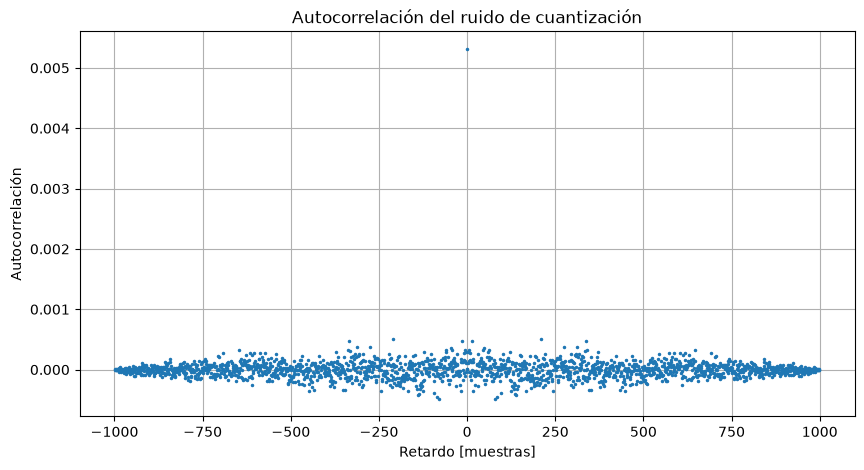

In [13]:
correlacion_nq = np.correlate(nq, nq, mode='full') / N
retardos = np.arange(-N+1, N)#para poner eje x en funcion de k y leer mejor la autocorrelacion
plt.figure(figsize=(10,5))
plt.plot(retardos,correlacion_nq,linestyle='None',marker='.',markersize=3)
plt.xlabel('Retardo [muestras]')
plt.ylabel('Autocorrelación')
plt.title('Autocorrelación del ruido de cuantización')
plt.grid()
plt.show()

Observamos que la autocorrelación presenta un pico claramente dominante para retardo nulo (k=0), mientras que para retardos distintos de cero los valores son mucho menores y oscilan alrededor de cero.

Este comportamiento indica que las muestras del error de cuantización son aproximadamente incorreladas y resulta consistente con el modelo ideal de ruido blanco.

Finalmente se realizó un *análisis en frecuencia*; se estudió la distribución espectral de potencia de la salida del ADC $s_Q$, del ruido analógico $n$ y del ruido de cuantización $n_q$.

Para ello se calculó la DFT de cada señal y, como se trabajó con señales reales, se representó únicamente la mitad positiva del espectro. A partir del módulo cuadrado de la DFT se obtuvo la potencia correspondiente a cada bin, expresándola luego en dB.

También se calculó el valor medio de la potencia de cada ruido para estimar su piso espectral.

Piso ruido analógico = -49.660630031122544 dB
Piso ruido cuantización = -49.81863602516049 dB


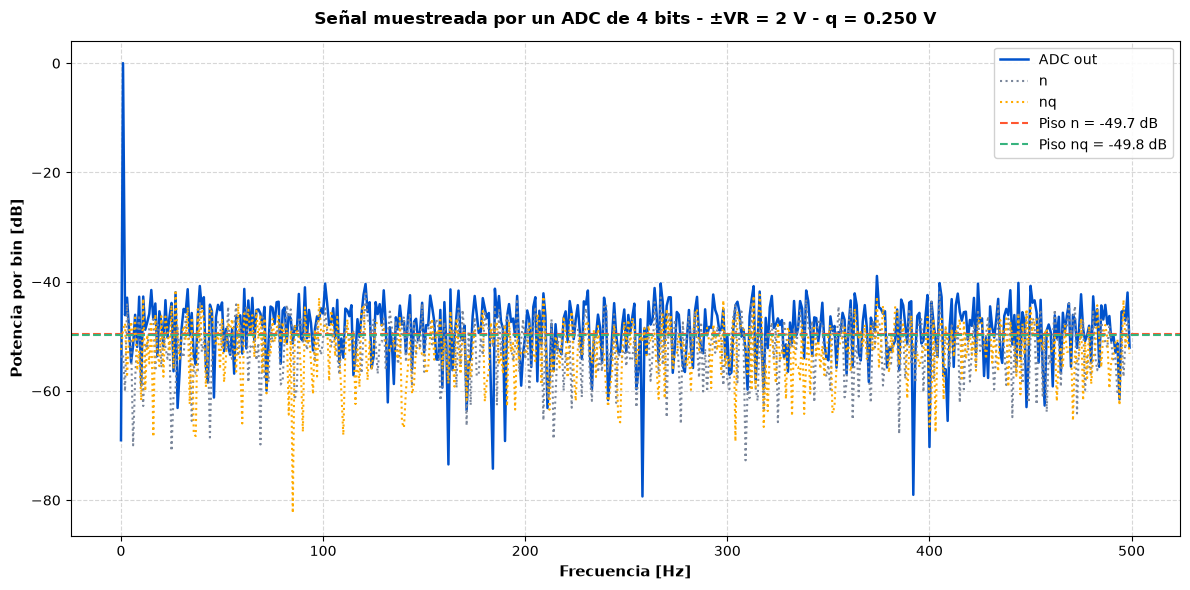

In [8]:
#%% FFT PARA ANALISIS ESPECTRAL

SQ = np.fft.fft(sQ)
N_ANALOG = np.fft.fft(n)
NQ = np.fft.fft(nq)
freq = np.arange(N//2) * fs/N#creamos eje de frecuencias genera 0,1,2...499
#calc potencia
PSD_sQ = 2 * np.abs(SQ[:N//2]/N)**2
PSD_n = 2 * np.abs(N_ANALOG[:N//2]/N)**2
PSD_nq = 2 * np.abs(NQ[:N//2]/N)**2
#pasamos a db
PSD_sQ_db = 10*np.log10(PSD_sQ)
PSD_n_db = 10*np.log10(PSD_n)
PSD_nq_db = 10*np.log10(PSD_nq)
#calculamos pisos de ruido
piso_n = 10*np.log10(np.mean(PSD_n))
piso_nq = 10*np.log10(np.mean(PSD_nq))

print("Piso ruido analógico =", piso_n, "dB")
print("Piso ruido cuantización =", piso_nq, "dB")

#%% GRAFICO ESPECTRAL FINAL

plt.figure(figsize=(12, 6))

# Señal principal (azul eléctrico intenso y línea más gruesa para resaltar)
plt.plot(freq, PSD_sQ_db, 
         color='#0052CC', 
         linewidth=1.8, 
         label='ADC out')

# Espectros de ruido (colores diferenciados y semitransparentes)
plt.plot(freq, 
         PSD_n_db, 
         color='#7A869A', 
         linestyle=':', 
         linewidth=1.5, 
         label='n')

plt.plot(freq, 
         PSD_nq_db, 
         color='#FFAB00', 
         linestyle=':', 
         linewidth=1.5, 
         label='nq')

# Pisos de ruido (líneas punteadas en tonos vivos alineados a sus referencias)
plt.axhline(piso_n, 
            color='#FF5630', 
            linestyle='--', 
            linewidth=1.5, 
            label=f'Piso n = {piso_n:.1f} dB')

plt.axhline(piso_nq, 
            color='#36B37E', 
            linestyle='--', 
            linewidth=1.5, 
            label=f'Piso nq = {piso_nq:.1f} dB')

plt.xlabel('Frecuencia [Hz]', fontsize=11, fontweight='bold')
plt.ylabel('Potencia por bin [dB]', fontsize=11, fontweight='bold')

plt.title(
    f'Señal muestreada por un ADC de {B} bits - '
    f'±VR = {vfs} V - q = {q:.3f} V',
    fontsize=12,
    fontweight='bold',
    pad=12
)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right', framealpha=0.9)
plt.tight_layout()
plt.show()

Tal como podemos observar en el gráfico anterior, en el espectro de la salida del ADC se observa un pico dominante en $f_0=1$ Hz, correspondiente a la frecuencia de la senoidal de entrada. Como la señal fue generada con potencia unitaria, dicho pico se encuentra aproximadamente en $0 dB$.

Por otro lado, tanto el ruido analógico $n$ como el ruido de cuantización $n_q$ presentan componentes distribuidas a lo largo de todo el rango de frecuencias analizado, sin una frecuencia claramente predominante.

Para este caso se obtuvieron pisos de ruido de aproximadamente -49.8 dB para $n$ y -49.6 dB para $n_q$\. Ambos valores son *prácticamente iguales*, lo cual coincide con lo esperado ya que se trabajó con $k_n=1$, y por lo tanto $P_n=P_q$.

La pequeña diferencia entre ambos pisos se debe a que se trabaja con una cantidad finita de muestras y con una realización aleatoria del ruido.


### b) Variación de $k_n$ para $B=4$
Una vez analizado el caso $k_n=1$, se estudió el efecto de modificar la potencia del ruido analógico manteniendo fija la resolución del ADC en $B=4$.

Como $P_n=k_nP_q$ y, para un mismo valor de $B$, la potencia de cuantización $P_q$ permanece constante, variar $k_n$ modifica directamente la potencia del ruido analógico agregado antes del ADC.

Se consideraron los casos $k_n=0.1$, $k_n=1$ y $k_n=10$.

#### Caso $k_n=0.1$

Para este caso se cumple $P_n=0.1P_q$, por lo que el ruido analógico tiene una potencia diez veces menor que el ruido de cuantización. Esta relación equivale a una diferencia aproximada de $10$ dB entre ambos niveles de potencia.
$$ 10\log_{10}\left(\frac{P_q}{P_n}\right) = 10\log_{10}(10) = 10\text{ dB} $$

Por lo tanto, se espera que el piso espectral asociado al ruido analógico se encuentre aproximadamente 10 dB por debajo del correspondiente al ruido de cuantización.

p-value = 0.023193499242459364
La señal NO es compatible con una distribución uniforme.
Piso ruido analógico = -60.090531404551456 dB
Piso ruido cuantización = -49.27246508854067 dB


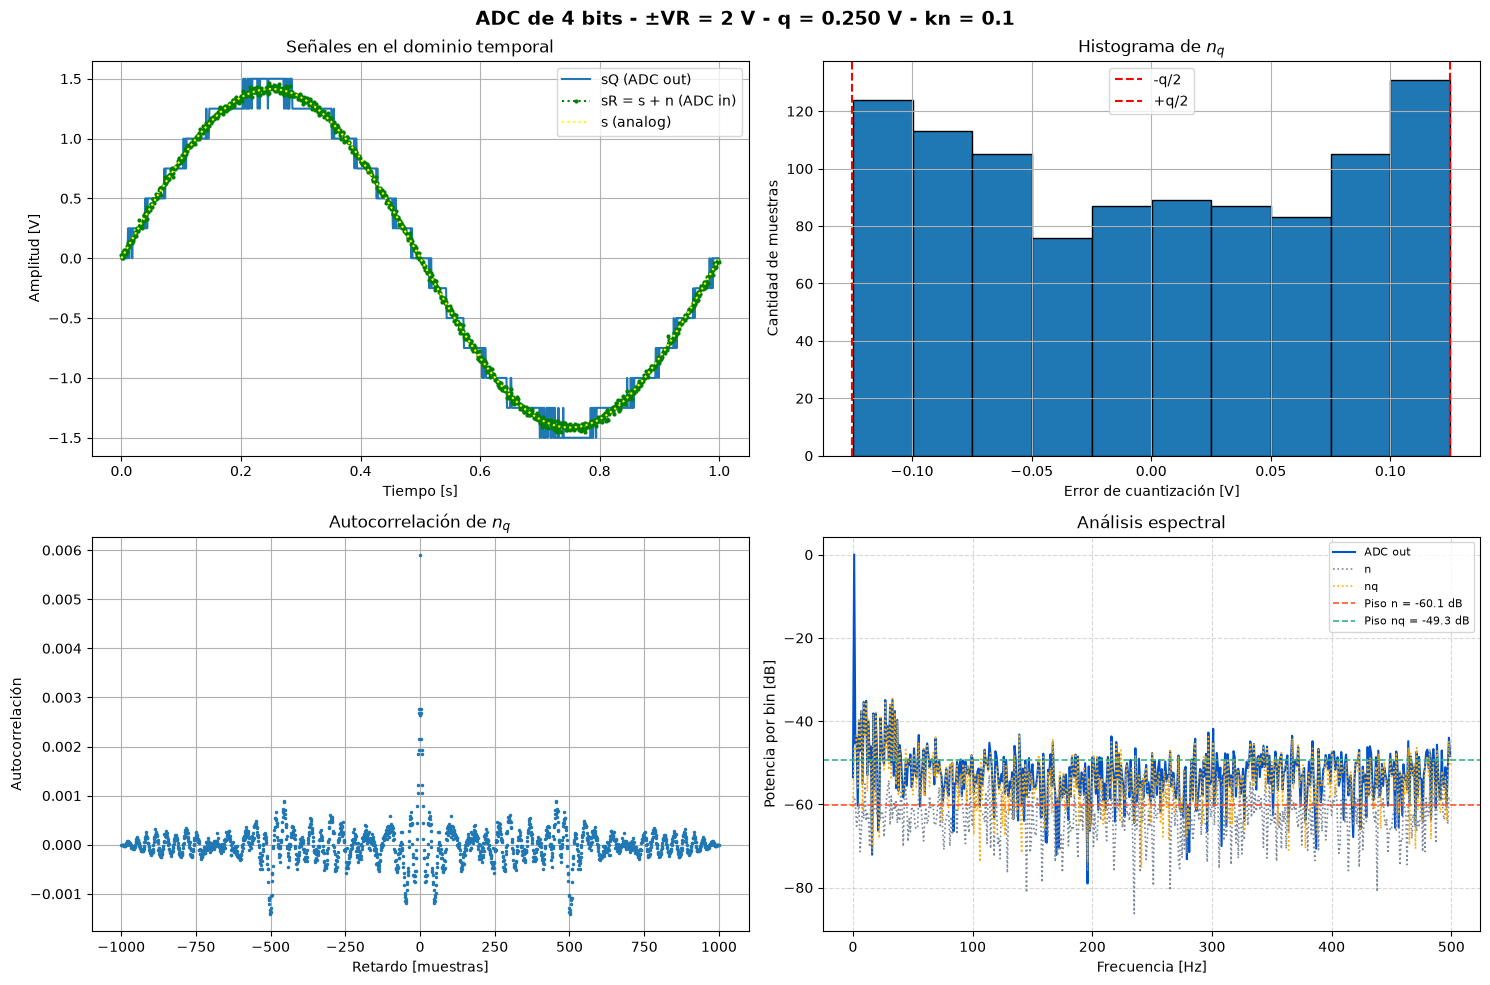

In [6]:
#%% CASO kn = 0.1 - modificamos variables dependientes de kn

kn = 0.1
Pn = kn * Pq
sigma_n = np.sqrt(Pn)
n = np.random.normal(0, sigma_n, N)
sR = s + n
sQ = np.round(sR/q) * q
nq = sQ - sR

#%% TEST KOLMOGOROV-SMIRNOV
a = -q/2
b = q/2

resultado = stats.kstest(
    nq,
    'uniform',
    args=(a, b-a))

alpha = 0.05

print("p-value =", resultado.pvalue)

if resultado.pvalue > alpha:
    print("La señal es compatible con una distribución uniforme.")
else:
    print("La señal NO es compatible con una distribución uniforme.")


#%% AUTOCORRELACION
correlacion_nq = np.correlate(
    nq,
    nq,
    mode='full'
) / N

retardos = np.arange(-N+1, N)

#%% ANALISIS ESPECTRAL

SQ = np.fft.fft(sQ)
N_ANALOG = np.fft.fft(n)
NQ = np.fft.fft(nq)

freq = np.arange(N//2) * fs/N

# potencia por bin
PSD_sQ = 2 * np.abs(SQ[:N//2]/N)**2
PSD_n = 2 * np.abs(N_ANALOG[:N//2]/N)**2
PSD_nq = 2 * np.abs(NQ[:N//2]/N)**2

# paso a dB
PSD_sQ_db = 10*np.log10(PSD_sQ + 1e-20)
PSD_n_db = 10*np.log10(PSD_n + 1e-20)
PSD_nq_db = 10*np.log10(PSD_nq + 1e-20)

# pisos de ruido
piso_n = 10*np.log10(np.mean(PSD_n))
piso_nq = 10*np.log10(np.mean(PSD_nq))

print("Piso ruido analógico =", piso_n, "dB")
print("Piso ruido cuantización =", piso_nq, "dB")


#%% FIGURA RESUMEN

fig, axs = plt.subplots(2, 2, figsize=(15, 10))


# --------------------------------------------------
# 1) GRAFICO TEMPORAL
# --------------------------------------------------

axs[0,0].plot(
    tt,
    sQ,
    label='sQ (ADC out)'
)

axs[0,0].plot(
    tt,
    sR,
    linestyle=':',
    marker='o',
    markersize=2,
    color='green',
    label='sR = s + n (ADC in)'
)

axs[0,0].plot(
    tt,
    s,
    linestyle=':',
    color='yellow',
    label='s (analog)'
)

axs[0,0].set_xlabel('Tiempo [s]')
axs[0,0].set_ylabel('Amplitud [V]')

axs[0,0].set_title(
    'Señales en el dominio temporal'
)

axs[0,0].grid()
axs[0,0].legend()


# --------------------------------------------------
# 2) HISTOGRAMA DEL RUIDO DE CUANTIZACION
# --------------------------------------------------

axs[0,1].hist(
    nq,
    bins=10,
    edgecolor='black'
)

axs[0,1].axvline(
    -q/2,
    color='red',
    linestyle='--',
    label='-q/2'
)

axs[0,1].axvline(
    q/2,
    color='red',
    linestyle='--',
    label='+q/2'
)

axs[0,1].set_xlabel('Error de cuantización [V]')
axs[0,1].set_ylabel('Cantidad de muestras')

axs[0,1].set_title(
    'Histograma de $n_q$'
)

axs[0,1].grid()
axs[0,1].legend()


# --------------------------------------------------
# 3) AUTOCORRELACION
# --------------------------------------------------

axs[1,0].plot(
    retardos,
    correlacion_nq,
    linestyle='None',
    marker='.',
    markersize=3
)

axs[1,0].set_xlabel('Retardo [muestras]')
axs[1,0].set_ylabel('Autocorrelación')

axs[1,0].set_title(
    'Autocorrelación de $n_q$'
)

axs[1,0].grid()


# --------------------------------------------------
# 4) ESPECTRO
# --------------------------------------------------

axs[1,1].plot(
    freq,
    PSD_sQ_db,
    color='#0052CC',
    linewidth=1.5,
    label='ADC out'
)

axs[1,1].plot(
    freq,
    PSD_n_db,
    color='#7A869A',
    linestyle=':',
    linewidth=1.2,
    label='n'
)

axs[1,1].plot(
    freq,
    PSD_nq_db,
    color='#FFAB00',
    linestyle=':',
    linewidth=1.2,
    label='nq'
)

axs[1,1].axhline(
    piso_n,
    color='#FF5630',
    linestyle='--',
    linewidth=1.2,
    label=f'Piso n = {piso_n:.1f} dB'
)

axs[1,1].axhline(
    piso_nq,
    color='#36B37E',
    linestyle='--',
    linewidth=1.2,
    label=f'Piso nq = {piso_nq:.1f} dB'
)

axs[1,1].set_xlabel('Frecuencia [Hz]')
axs[1,1].set_ylabel('Potencia por bin [dB]')

axs[1,1].set_title(
    'Análisis espectral'
)

axs[1,1].grid(True, linestyle='--', alpha=0.5)
axs[1,1].legend(fontsize=8)


# titulo general
fig.suptitle(
    f'ADC de {B} bits - ±VR = {vfs} V - '
    f'q = {q:.3f} V - kn = {kn}',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

Observando los gráficos anteriores:
En el *dominio temporal*, la señal $s_R$ se observa más próxima a la senoidal ideal que en el caso $k_n=1$, debido a la menor potencia del ruido analógico. La salida $s_Q$ continúa presentando niveles separados por $q=0.25$ V, ya que el paso de cuantización depende de $B$ y del rango del ADC, parámetros que no fueron modificados.

En cuanto la *error de cuantización*, observamos que su *histograma*, a diferencia del caso (kn=1) presenta una distribución menos plana; y al aplicarse nuevamente el test de Kolmogorov-Smirnov se rechazó la hipótesis de compatibilidad con dicha distribucion. Esto puede asociarse a que al tener poco ruido analógico agregado, la entrada al ADC conserva una mayor componente determinística asociada a la senoidal. Entonces, el error de cuantización queda más relacionado con la evolución de la señal y el modelo uniforme ideal resulta menos adecuado para este caso. No está tan “aleatorizado”.

En cuanto a la *autocorrelación*, si bien se mantiene un máximo dominante para retardo nulo; aparecen valores distintos de cero para k distintos de cero. Por lo tanto, en este caso el error de cuantización presenta una mayor correlación entre muestras que para kn=1. Esto también se debe a que al haber poco ruido analógico agregado el error de cuantización se "asemeja" más a la senoidal y no resulta tan aleatorio ni incorrelado. 

Por último, en *frecuencia*, se observa nuevamente la componente principal de la señal de salida en $f_0=1$ Hz y en cuanto a los ruidos; el piso del ruido analógico se ubica aproximadamente $10$ dB por debajo del piso del ruido de cuantización, tal como se esperaba a partir de la relación $P_n=0.1P_q$ .El piso promedio del ruido analógico resultó:

$$ \text{Piso}_n=-59.4\text{ dB} $$

mientras que para el ruido de cuantización se obtuvo:

$$ \text{Piso}_{n_q}=-49.4\text{ dB} $$

En efecto, al cumplirse $P_n=0.1P_q$, el ruido analógico posee una potencia diez veces menor y, por lo tanto, su nivel espectral promedio se encuentra aproximadamente 10 dB por debajo del correspondiente al ruido de cuantización.


#### Caso $k_n=10$
Para este caso:

$$ P_n=10P_q $$

por lo que el ruido analógico posee una potencia diez veces mayor que la del ruido de cuantización. En términos de potencia expresada en dB, esto corresponde a una diferencia aproximada de:

$$ 10\log_{10}(10)=10\text{ dB} $$

Por lo tanto, se espera que el piso espectral del ruido analógico se encuentre aproximadamente 10 dB por encima del piso del ruido de cuantización.


p-value = 0.4360785872983104
La señal es compatible con una distribución uniforme.
Piso ruido analógico = -39.81071496284231 dB
Piso ruido cuantización = -49.791477073983415 dB


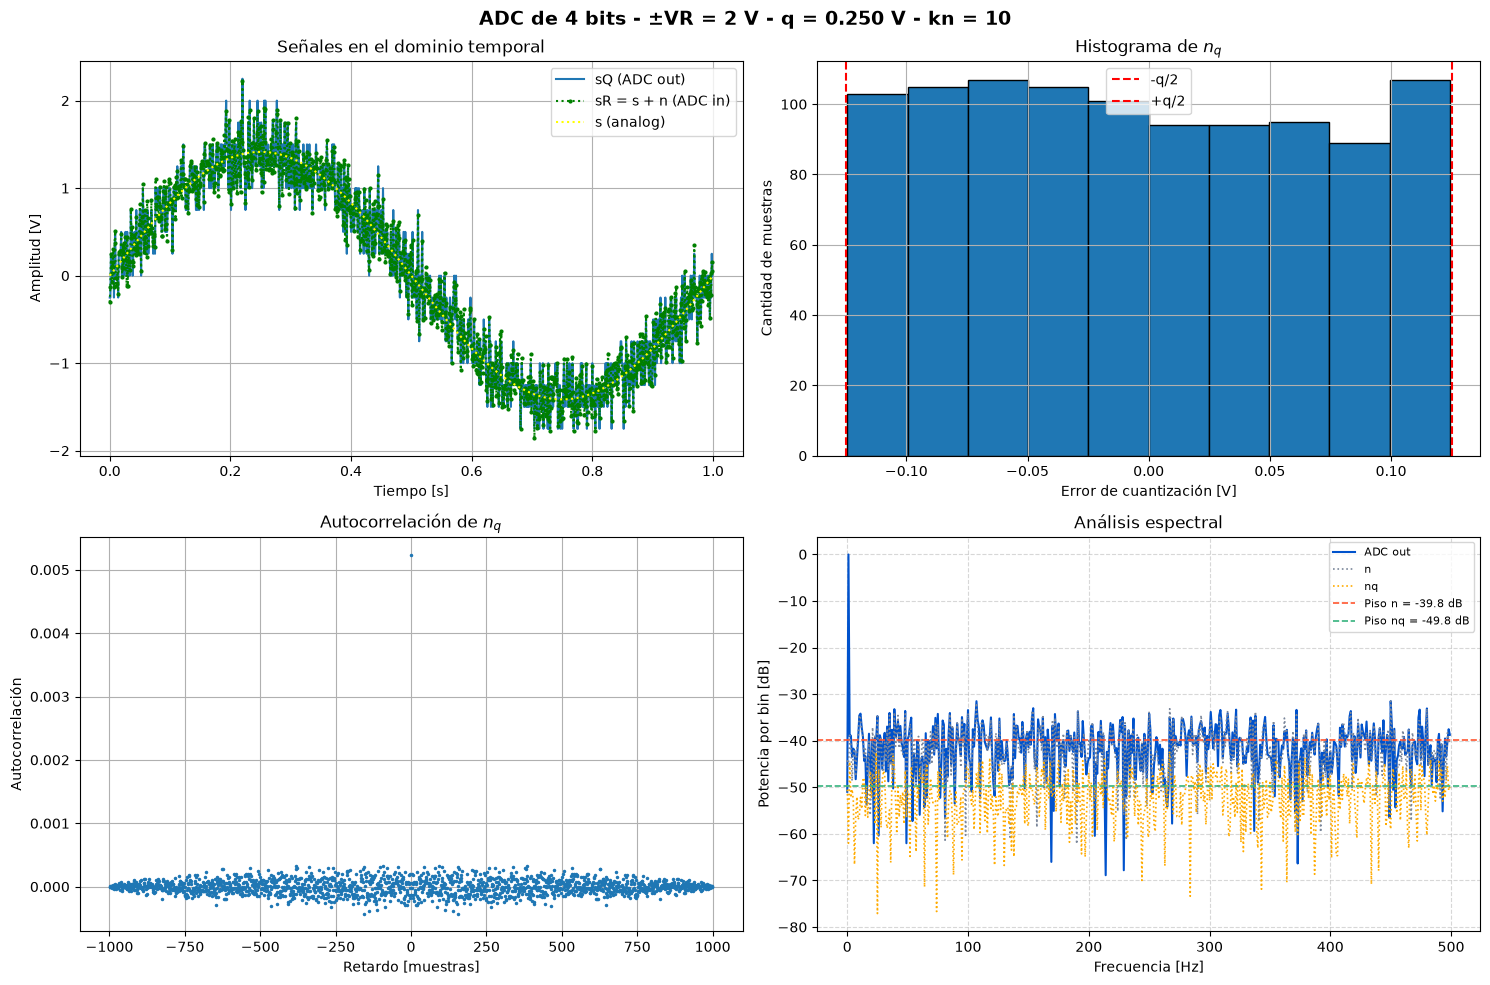

In [7]:
#%% CASO kn = 10 - modificamos variables dependientes de kn

kn = 10

Pn = kn * Pq
sigma_n = np.sqrt(Pn)

n = np.random.normal(0, sigma_n, N)

sR = s + n
sQ = np.round(sR/q) * q
nq = sQ - sR


#%% TEST KOLMOGOROV-SMIRNOV

a = -q/2
b = q/2

resultado = stats.kstest(
    nq,
    'uniform',
    args=(a, b-a)
)

alpha = 0.05

print("p-value =", resultado.pvalue)

if resultado.pvalue > alpha:
    print("La señal es compatible con una distribución uniforme.")
else:
    print("La señal NO es compatible con una distribución uniforme.")


#%% AUTOCORRELACION

correlacion_nq = np.correlate(
    nq,
    nq,
    mode='full'
) / N

retardos = np.arange(-N+1, N)


#%% ANALISIS ESPECTRAL

SQ = np.fft.fft(sQ)
N_ANALOG = np.fft.fft(n)
NQ = np.fft.fft(nq)

freq = np.arange(N//2) * fs/N

# potencia por bin
PSD_sQ = 2 * np.abs(SQ[:N//2]/N)**2
PSD_n = 2 * np.abs(N_ANALOG[:N//2]/N)**2
PSD_nq = 2 * np.abs(NQ[:N//2]/N)**2

# paso a dB
PSD_sQ_db = 10*np.log10(PSD_sQ + 1e-20)
PSD_n_db = 10*np.log10(PSD_n + 1e-20)
PSD_nq_db = 10*np.log10(PSD_nq + 1e-20)

# pisos de ruido
piso_n = 10*np.log10(np.mean(PSD_n))
piso_nq = 10*np.log10(np.mean(PSD_nq))

print("Piso ruido analógico =", piso_n, "dB")
print("Piso ruido cuantización =", piso_nq, "dB")


#%% FIGURA RESUMEN

fig, axs = plt.subplots(2, 2, figsize=(15, 10))


# --------------------------------------------------
# 1) GRAFICO TEMPORAL
# --------------------------------------------------

axs[0,0].plot(
    tt,
    sQ,
    label='sQ (ADC out)'
)

axs[0,0].plot(
    tt,
    sR,
    linestyle=':',
    marker='o',
    markersize=2,
    color='green',
    label='sR = s + n (ADC in)'
)

axs[0,0].plot(
    tt,
    s,
    linestyle=':',
    color='yellow',
    label='s (analog)'
)

axs[0,0].set_xlabel('Tiempo [s]')
axs[0,0].set_ylabel('Amplitud [V]')
axs[0,0].set_title('Señales en el dominio temporal')
axs[0,0].grid()
axs[0,0].legend()


# --------------------------------------------------
# 2) HISTOGRAMA DEL RUIDO DE CUANTIZACION
# --------------------------------------------------

axs[0,1].hist(
    nq,
    bins=10,
    edgecolor='black'
)

axs[0,1].axvline(
    -q/2,
    color='red',
    linestyle='--',
    label='-q/2'
)

axs[0,1].axvline(
    q/2,
    color='red',
    linestyle='--',
    label='+q/2'
)

axs[0,1].set_xlabel('Error de cuantización [V]')
axs[0,1].set_ylabel('Cantidad de muestras')
axs[0,1].set_title('Histograma de $n_q$')
axs[0,1].grid()
axs[0,1].legend()


# --------------------------------------------------
# 3) AUTOCORRELACION
# --------------------------------------------------

axs[1,0].plot(
    retardos,
    correlacion_nq,
    linestyle='None',
    marker='.',
    markersize=3
)

axs[1,0].set_xlabel('Retardo [muestras]')
axs[1,0].set_ylabel('Autocorrelación')
axs[1,0].set_title('Autocorrelación de $n_q$')
axs[1,0].grid()


# --------------------------------------------------
# 4) ESPECTRO
# --------------------------------------------------

axs[1,1].plot(
    freq,
    PSD_sQ_db,
    color='#0052CC',
    linewidth=1.5,
    label='ADC out'
)

axs[1,1].plot(
    freq,
    PSD_n_db,
    color='#7A869A',
    linestyle=':',
    linewidth=1.2,
    label='n'
)

axs[1,1].plot(
    freq,
    PSD_nq_db,
    color='#FFAB00',
    linestyle=':',
    linewidth=1.2,
    label='nq'
)

axs[1,1].axhline(
    piso_n,
    color='#FF5630',
    linestyle='--',
    linewidth=1.2,
    label=f'Piso n = {piso_n:.1f} dB'
)

axs[1,1].axhline(
    piso_nq,
    color='#36B37E',
    linestyle='--',
    linewidth=1.2,
    label=f'Piso nq = {piso_nq:.1f} dB'
)

axs[1,1].set_xlabel('Frecuencia [Hz]')
axs[1,1].set_ylabel('Potencia por bin [dB]')
axs[1,1].set_title('Análisis espectral')
axs[1,1].grid(True, linestyle='--', alpha=0.5)
axs[1,1].legend(fontsize=8)


# titulo general
fig.suptitle(
    f'ADC de {B} bits - ±VR = {vfs} V - '
    f'q = {q:.3f} V - kn = {kn}',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

En el *dominio temporal* se observa que la señal $s_R$ presenta una dispersión mayor alrededor de la senoidal ideal debido al aumento del ruido analógico. Como $s_Q$ resulta de cuantizar esta señal, la salida del ADC también se ve más perturbada. Sin embargo, el paso de cuantización continúa siendo $q=0.25$ V, ya que $B$ y el rango del ADC permanecen constantes.

El *histograma* del error de cuantización continúa limitado al intervalo $[-q/2,\ q/2]$ y presenta similitud con un histograma esperado para una distribución uniforme. Además, el test de Kolmogorov-Smirnov indicó que la señal es compatible con una distribución uniforme.

La *autocorrelación* vuelve a presentar un pico dominante para retardo nulo y valores mucho menores para los demás retardos, mostrando un comportamiento aproximadamente incorrelado. Al aumentar el ruido analógico, el error de cuantización queda menos relacionado con la forma determinística de la senoidal.

En el *dominio frecuencial*, el piso medio del ruido analógico resultó de aproximadamente -39.9 dB, mientras que el correspondiente al ruido de cuantización fue de aproximadamente -49.8 dB. La diferencia entre ambos valores es cercana a 10 dB, como se esperaba a partir de la relación: $$ P_n=10P_q $$

Por lo tanto, el ruido analógico presenta un piso espectral aproximadamente 10 dB superior al del ruido de cuantización. En este caso, el ruido analógico es el principal aporte de ruido en la señal de salida.



#### Comparación para $B=4$ con $k_n=0.1$, $k_n=1$ y $k_n=10$

Como se mencionó previamente, al mantener $B=4$, el paso de cuantización permanece constante en:$$q=0.25\ \text{V}$$

Por lo tanto, al modificar $k_n$ lo que cambia es la potencia del ruido analógico agregado antes del ADC, ya que:

$$P_n=k_nP_q$$

Para $k_n=0.1$, el ruido analógico tiene una potencia diez veces menor que el ruido de cuantización. Esto se observa en el dominio temporal, donde $s_R$ permanece más próxima a la senoidal ideal, y en frecuencia, donde el piso de $n$ aparece aproximadamente $10$ dB por debajo del piso de $n_q$.

Para $k_n=1$, ambas potencias son aproximadamente iguales, $P_n=P_q$, por lo que los pisos espectrales de ambos ruidos se encuentran prácticamente al mismo nivel.

Finalmente, para $k_n=10$, el ruido analógico tiene una potencia diez veces mayor que el ruido de cuantización. En este caso, $s_R$ presenta una mayor dispersión alrededor de la senoidal y el piso de $n$ se encuentra aproximadamente $10$ dB por encima del piso de $n_q$.

En síntesis, el valor de $k_n$ determina cuál de los dos ruidos tiene mayor peso:

- Si $k_n<1$, el ruido analógico es menor que el ruido de cuantización.
- Si $k_n=1$, ambos tienen aproximadamente la misma potencia.
- Si $k_n>1$, el ruido analógico pasa a ser mayor que el ruido de cuantización.

Entonces ya analizamos el efecto de variar $k_n$ para un mismo número de bits. Veamos ahora el efecto de modificar la resolución del ADC. Para evitar repetir el mismo análisis, se mantuvo $k_n=1$ y se repitió la simulación para $B=8$ y $B=16$. De esta manera, las diferencias observadas pueden atribuirse principalmente al cambio en la cantidad de bits del convertidor.

Como:

$$q=\frac{2V_F}{2^B}$$

al aumentar $B$, el paso de cuantización disminuye y los niveles disponibles quedan cada vez más próximos entre sí. A su vez, como la potencia teórica del ruido de cuantización está dada por:

$$P_q=\frac{q^2}{12}$$

una disminución de $q$ produce una reducción importante de $P_q$.

Para los casos analizados se mantuvo $k_n=1$, por lo que también se cumple $P_n=P_q$. En consecuencia, al aumentar $B$ disminuyen tanto la potencia del ruido de cuantización como la potencia del ruido analógico utilizado en la simulación.


### Caso $B=8$, $k_n=1$
Al aumentar la resolución del ADC a $B=8$ bits, manteniendo $V_F=2$ V, el paso de cuantización disminuye a:

$$ q=\frac{4}{2^8}=0.015625\text{ V} $$

Como se mencionó anteriormente, continúa cumpliéndose $ P_n=P_q $. Sin embargo, como $P_q=q^2/12$, y $q$ disminuye, ambas potencias disminuyen respecto del caso de $B=4$.


Piso ruido analógico = -73.83519435916975 dB
Piso ruido cuantización = -73.75788288463804 dB


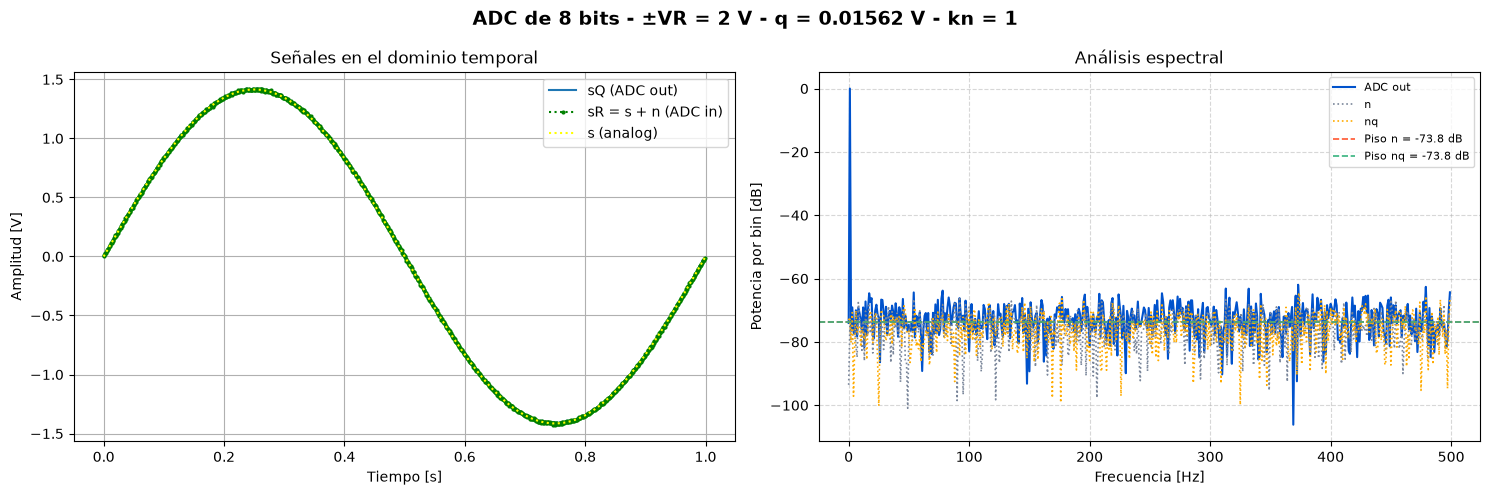

In [8]:
#%% CASO B = 8, kn = 1

B = 8
kn = 1

q = (2*vfs)/(2**B)

Pq = q**2 / 12
Pn = kn * Pq

sigma_n = np.sqrt(Pn)

n = np.random.normal(0, sigma_n, N)

sR = s + n
sQ = np.round(sR/q) * q
nq = sQ - sR


#%% ANALISIS ESPECTRAL

SQ = np.fft.fft(sQ)
N_ANALOG = np.fft.fft(n)
NQ = np.fft.fft(nq)

freq = np.arange(N//2) * fs/N

# potencia por bin
PSD_sQ = 2 * np.abs(SQ[:N//2]/N)**2
PSD_n = 2 * np.abs(N_ANALOG[:N//2]/N)**2
PSD_nq = 2 * np.abs(NQ[:N//2]/N)**2

# paso a dB
PSD_sQ_db = 10*np.log10(PSD_sQ + 1e-20)
PSD_n_db = 10*np.log10(PSD_n + 1e-20)
PSD_nq_db = 10*np.log10(PSD_nq + 1e-20)

# pisos de ruido
piso_n = 10*np.log10(np.mean(PSD_n))
piso_nq = 10*np.log10(np.mean(PSD_nq))

print("Piso ruido analógico =", piso_n, "dB")
print("Piso ruido cuantización =", piso_nq, "dB")


#%% FIGURA RESUMEN

fig, axs = plt.subplots(1, 2, figsize=(15, 5))


# --------------------------------------------------
# 1) GRAFICO TEMPORAL
# --------------------------------------------------

axs[0].plot(
    tt,
    sQ,
    label='sQ (ADC out)'
)

axs[0].plot(
    tt,
    sR,
    linestyle=':',
    marker='o',
    markersize=2,
    color='green',
    label='sR = s + n (ADC in)'
)

axs[0].plot(
    tt,
    s,
    linestyle=':',
    color='yellow',
    label='s (analog)'
)

axs[0].set_xlabel('Tiempo [s]')
axs[0].set_ylabel('Amplitud [V]')
axs[0].set_title('Señales en el dominio temporal')
axs[0].grid()
axs[0].legend()


# --------------------------------------------------
# 2) ANALISIS ESPECTRAL
# --------------------------------------------------

axs[1].plot(
    freq,
    PSD_sQ_db,
    color='#0052CC',
    linewidth=1.5,
    label='ADC out'
)

axs[1].plot(
    freq,
    PSD_n_db,
    color='#7A869A',
    linestyle=':',
    linewidth=1.2,
    label='n'
)

axs[1].plot(
    freq,
    PSD_nq_db,
    color='#FFAB00',
    linestyle=':',
    linewidth=1.2,
    label='nq'
)

axs[1].axhline(
    piso_n,
    color='#FF5630',
    linestyle='--',
    linewidth=1.2,
    label=f'Piso n = {piso_n:.1f} dB'
)

axs[1].axhline(
    piso_nq,
    color='#36B37E',
    linestyle='--',
    linewidth=1.2,
    label=f'Piso nq = {piso_nq:.1f} dB'
)

axs[1].set_xlabel('Frecuencia [Hz]')
axs[1].set_ylabel('Potencia por bin [dB]')
axs[1].set_title('Análisis espectral')
axs[1].grid(True, linestyle='--', alpha=0.5)
axs[1].legend(fontsize=8)


# titulo general
fig.suptitle(
    f'ADC de {B} bits - ±VR = {vfs} V - '
    f'q = {q:.5f} V - kn = {kn}',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

En el *dominio temporal* se observa que las señales $s$, $s_R$ y $s_Q$ aparecen mucho más próximas entre sí que para $B=4$. Esto se debe a que, al aumentar la cantidad de bits, el paso de cuantización disminuye de $0.25$ V a aproximadamente $0.0156$ V. Como consecuencia, los niveles disponibles se encuentran mucho más próximos entre sí y la diferencia entre la entrada y la salida del ADC disminuye considerablemente.

En *frecuencia*, los pisos del ruido analógico y del ruido de cuantización vuelven a quedar prácticamente al mismo nivel, ya que como se mencionó previamente, se mantuvo $k_n=1$. Sin embargo, para $B=8$ se obtuvieron valores cercanos a $-74$ dB para ambos pisos, mientras que para $B=4$ se encontraban alrededor de $-50$ dB. Esto representa una disminución aproximada de $24$ dB en el nivel de ruido.
Este resultado coincide con la mejora esperada de aproximadamente $6$ dB de SNR por cada bit adicional.

Por lo tanto, aumentar la cantidad de bits mejora considerablemente la resolución del ADC y reduce la potencia asociada al error de cuantización.


### Caso $B=16$, $k_n=1$
Por último, se aumentó la resolución del ADC a $B=16$ bits, manteniendo nuevamente $k_n=1$.

En este caso, el paso de cuantización resulta:

$$
q=\frac{2V_F}{2^{16}}\approx 6.10\times10^{-5}\ \text{V}
$$

Este valor es mucho menor que en los casos anteriores, por lo que los niveles de cuantización se encuentran extremadamente próximos entre sí. Como además se mantiene $k_n=1$, se cumple nuevamente $P_n=P_q$, y ambas potencias disminuyen junto con $q$.

Piso ruido analógico = -122.08626984931303 dB
Piso ruido cuantización = -121.95823790245717 dB


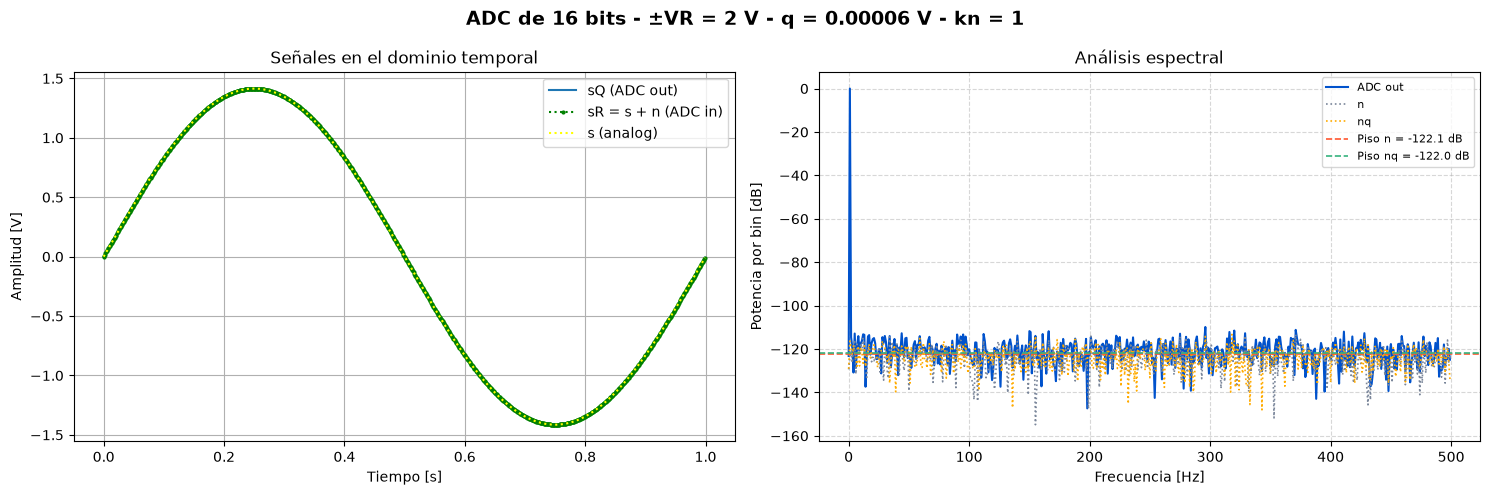

In [9]:
#%% CASO B = 16, kn = 1

B = 16
kn = 1

q = (2*vfs)/(2**B)

Pq = q**2 / 12
Pn = kn * Pq

sigma_n = np.sqrt(Pn)

n = np.random.normal(0, sigma_n, N)

sR = s + n
sQ = np.round(sR/q) * q
nq = sQ - sR


#%% ANALISIS ESPECTRAL

SQ = np.fft.fft(sQ)
N_ANALOG = np.fft.fft(n)
NQ = np.fft.fft(nq)

freq = np.arange(N//2) * fs/N

# potencia por bin
PSD_sQ = 2 * np.abs(SQ[:N//2]/N)**2
PSD_n = 2 * np.abs(N_ANALOG[:N//2]/N)**2
PSD_nq = 2 * np.abs(NQ[:N//2]/N)**2

# paso a dB
PSD_sQ_db = 10*np.log10(PSD_sQ + 1e-20)
PSD_n_db = 10*np.log10(PSD_n + 1e-20)
PSD_nq_db = 10*np.log10(PSD_nq + 1e-20)

# pisos de ruido
piso_n = 10*np.log10(np.mean(PSD_n))
piso_nq = 10*np.log10(np.mean(PSD_nq))

print("Piso ruido analógico =", piso_n, "dB")
print("Piso ruido cuantización =", piso_nq, "dB")


#%% FIGURA RESUMEN

fig, axs = plt.subplots(1, 2, figsize=(15, 5))


# --------------------------------------------------
# 1) GRAFICO TEMPORAL
# --------------------------------------------------

axs[0].plot(
    tt,
    sQ,
    label='sQ (ADC out)'
)

axs[0].plot(
    tt,
    sR,
    linestyle=':',
    marker='o',
    markersize=2,
    color='green',
    label='sR = s + n (ADC in)'
)

axs[0].plot(
    tt,
    s,
    linestyle=':',
    color='yellow',
    label='s (analog)'
)

axs[0].set_xlabel('Tiempo [s]')
axs[0].set_ylabel('Amplitud [V]')
axs[0].set_title('Señales en el dominio temporal')
axs[0].grid()
axs[0].legend()


# --------------------------------------------------
# 2) ANALISIS ESPECTRAL
# --------------------------------------------------

axs[1].plot(
    freq,
    PSD_sQ_db,
    color='#0052CC',
    linewidth=1.5,
    label='ADC out'
)

axs[1].plot(
    freq,
    PSD_n_db,
    color='#7A869A',
    linestyle=':',
    linewidth=1.2,
    label='n'
)

axs[1].plot(
    freq,
    PSD_nq_db,
    color='#FFAB00',
    linestyle=':',
    linewidth=1.2,
    label='nq'
)

axs[1].axhline(
    piso_n,
    color='#FF5630',
    linestyle='--',
    linewidth=1.2,
    label=f'Piso n = {piso_n:.1f} dB'
)

axs[1].axhline(
    piso_nq,
    color='#36B37E',
    linestyle='--',
    linewidth=1.2,
    label=f'Piso nq = {piso_nq:.1f} dB'
)

axs[1].set_xlabel('Frecuencia [Hz]')
axs[1].set_ylabel('Potencia por bin [dB]')
axs[1].set_title('Análisis espectral')
axs[1].grid(True, linestyle='--', alpha=0.5)
axs[1].legend(fontsize=8)


# titulo general
fig.suptitle(
    f'ADC de {B} bits - ±VR = {vfs} V - '
    f'q = {q:.5f} V - kn = {kn}',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

En el *dominio temporal*, las señales $s$, $s_R$ y $s_Q$ resultan prácticamente indistinguibles en la escala del gráfico. Esto se debe a que, con $B=16$, el paso de cuantización es extremadamente pequeño y la salida del ADC puede aproximar la señal de entrada con mucha mayor precisión. El error introducido por la cuantización resulta muy pequeño respecto de la amplitud de la señal.


En *frecuencia*, ambos pisos se ubican alrededor de $-122$ dB, lo que representa una nueva disminución importante respecto de $B=8$, donde se encontraban aproximadamente en $-74$ dB. Se observa una disminución cercana a 48 dB. Esto coincide con lo esperado al aumentar la resolución en 8 bits, considerando una mejora aproximada de 6 dB por cada bit adicional.

#### Comparación para $k_n=1$ con $B=4$, $B=8$ y $B=16$
Al comparar los tres casos, se observa que al pasar de $B=4$ a $B=8$ el piso de ruido disminuye aproximadamente $24$ dB, mientras que de $B=8$ a $B=16$ disminuye alrededor de $48$ dB, en concordancia con una mejora cercana a $6$ dB por cada bit adicional.

Al aumentar la cantidad de bits disminuye fuertemente el paso de cuantización y, en consecuencia, la potencia del ruido de cuantización. En este caso particular, como $k_n=1$, también disminuye en la misma proporción la potencia del ruido analógico agregado.


## Bonus
### Relación entre cantidad de bits y SNR

Holton, en el capítulo 6.7, expresa la siguiente relación entre la cantidad de bits de un ADC y la relación señal-ruido asociada al proceso de cuantización:

$$SNR = 6.02B + 10.79 + 20\log_{10}\left(\frac{\sigma_x}{V_{FS}}\right)$$

donde:

- $B$: cantidad de bits del ADC.
- $\sigma_x$: desvío estándar de la señal de entrada. Para una señal de media nula, coincide con su valor RMS.
- $V_{FS}$: rango total del convertidor.
- $SNR$: relación señal-ruido expresada en dB.

En nuestro caso, la senoidal tiene media nula y potencia unitaria, por lo que $P_s=\sigma_x^2=1$ y, en consecuencia, $\sigma_x=1$.
Además, el ADC trabaja en un rango de $\pm 2$ V, por lo que el rango total utilizado en la expresión de Holton es: $V_{FS}=4\text{ V}$.
Reemplazando estos valores en la expresión anterior: 
$$\boxed{SNR \approx 6.02B - 1.25\text{ dB}}$$

Esta expresión permite calcular el SNR teórico correspondiente a cada resolución utilizada en la simulación.

La expresión $SNR\approx6.02B+1.76$ dB corresponde al caso de una senoidal que aprovecha completamente el rango disponible del ADC. En nuestra simulación la señal tiene amplitud $\sqrt{2}$ V, por lo que no alcanza los límites de $\pm2$ V del convertidor. Como consecuencia, se obtiene un SNR aproximadamente $3$ dB menor que en el caso de una senoidal a escala completa.

Para comparar la expresión teórica con la simulación, se calcularon para $B=4$, $8$ y $16$ bits:

- el SNR teórico mediante la expresión de Holton;
- el SNR asociado únicamente al error de cuantización medido;
- el SNR total de la digitalización, considerando conjuntamente el ruido analógico y la cuantización.


In [10]:
#%% BONUS - SNR EN FUNCION DE LA CANTIDAD DE BITS

B_valores = [4, 8, 16]# valores de B que queremos comparar
sigma_x = np.std(s)
VFS = 2 * vfs
kn_bonus = 1 # mantenemos kn = 1 para comparar solamente el efecto de B
resultados = []

for B_aux in B_valores:
    q_aux = (2 * vfs) / (2**B_aux)
    Pq_aux = q_aux**2 / 12# potencia teorica del ruido de cuantizacion
    Pn_aux = kn_bonus * Pq_aux  # potencia del ruido analogico
    sigma_n_aux = np.sqrt(Pn_aux)# genero el ruido analogico
    n_aux = np.random.normal(0, sigma_n_aux, N)
    sR_aux = s + n_aux
    sQ_aux = np.round(sR_aux / q_aux) * q_aux
    nq_aux = sQ_aux - sR_aux    

    # SNR TEORICO SEGUN HOLTON

    SNR_teorico = (6.02 * B_aux+ 10.79+ 20 * np.log10(sigma_x / VFS))

    # SNR MEDIDO DE CUANTIZACION
    # potencia señal / potencia error de cuantizacion
    SNR_cuant_medido = 10 * np.log10(np.var(s) / np.var(nq_aux))

    # SNR TOTAL DE LA DIGITALIZACION
    # compara la salida del ADC con la senoidal ideal incluye ruido analogico + cuantizacion

    error_total = sQ_aux - s

    SNR_digital = 10 * np.log10( np.var(s) / np.var(error_total))

    # guardamos resultados
    resultados.append([B_aux,q_aux,SNR_teorico,SNR_cuant_medido,SNR_digital])


#%% TABLA COMPARATIVA

print()
print("TABLA COMPARATIVA DE SNR")
print()

print(
    f"{'B [bits]':<10}"
    f"{'q [V]':<15}"
    f"{'SNR Holton [dB]':<20}"
    f"{'SNR cuant. [dB]':<20}"
    f"{'SNR total [dB]':<20}"
)

print("-"*85)

for fila in resultados:
    B_aux, q_aux, snr_teo, snr_cuant, snr_total = fila
    print(
        f"{B_aux:<10}"
        f"{q_aux:<15.6e}"
        f"{snr_teo:<20.2f}"
        f"{snr_cuant:<20.2f}"
        f"{snr_total:<20.2f}")



TABLA COMPARATIVA DE SNR

B [bits]  q [V]          SNR Holton [dB]     SNR cuant. [dB]     SNR total [dB]      
-------------------------------------------------------------------------------------
4         2.500000e-01   22.83               22.66               19.52               
8         1.562500e-02   46.91               46.91               43.74               
16        6.103516e-05   95.07               94.96               92.05               


Los resultados muestran una muy buena concordancia entre el SNR teórico obtenido mediante la expresión de Holton y el SNR de cuantización calculado a partir de la simulación. Para $B=4$, $8$ y $16$ bits, las diferencias entre ambos valores son pequeñas, lo que confirma la relación esperada entre la cantidad de bits y el ruido de cuantización.

Además, se verifica que cada bit adicional mejora el SNR aproximadamente $6.02$ dB. Por este motivo, al pasar de $4$ a $8$ bits el aumento es cercano a $24$ dB, mientras que al pasar de $8$ a $16$ bits es de aproximadamente $48$ dB.

El SNR total de la señal digitalizada resulta alrededor de $3$ dB menor que el SNR correspondiente únicamente a cuantización. Esto se debe a que se mantuvo $k_n=1$, por lo que $P_n=P_q$. Al contribuir dos fuentes de ruido de potencias similares al error total, la potencia de ruido aproximadamente se duplica, lo que representa una disminución cercana a:

$$10\log_{10}(2)\approx3\text{ dB}$$

## Conclusión

En este trabajo se pudo observar cómo influyen tanto el ruido analógico como la resolución del ADC sobre la señal digitalizada.

Al mantener fija la cantidad de bits, la relación entre la potencia del ruido analógico y la potencia del ruido de cuantización determina cuál de los dos tiene mayor importancia. Si $P_n<P_q$, el ruido de cuantización es el aporte dominante y su piso espectral queda por encima del correspondiente al ruido analógico. Si $P_n=P_q$, ambos pisos aparecen aproximadamente al mismo nivel. En cambio, si $P_n>P_q$, el ruido analógico pasa a ser el aporte dominante y su piso queda por encima del ruido de cuantización.

También se observó que, al disminuir el ruido analógico, la señal de entrada al ADC $s_R$ se aproxima más a la senoidal ideal. Sin embargo, en estas condiciones el error de cuantización puede quedar más relacionado con la forma de la señal, por lo que resulta menos aleatorio y puede presentar una mayor correlación entre muestras. Al aumentar el ruido analógico, esta dependencia se reduce y el error de cuantización se comporta de manera más similar al modelo de ruido uniforme e incorrelado.

Por otro lado, aumentar la cantidad de bits mejora notablemente la resolución del ADC. Como el paso de cuantización está dado por $q=\frac{2V_F}{2^B},$
al aumentar $B$, los niveles de cuantización quedan cada vez más próximos entre sí. Esto hace que disminuya el error de cuantización y, por lo tanto, también su potencia.

Este efecto también se refleja en la relación señal-ruido. Los resultados obtenidos coincidieron con la expresión teórica propuesta por Holton y mostraron que, aproximadamente, cada bit adicional aumenta el SNR de cuantización en $6.02$ dB. Por lo tanto, una mayor cantidad de bits permite representar la señal con mayor precisión y con un menor aporte relativo del ruido de cuantización.
